# Planning engines: which approach, and why

Every engine is run on the same problems and judged by the same production checker (`ConstraintRegistry` through `PlanVerification`, stricter than the booklet's `check_allocation.py`, which ignores windows and fuel).

| Id | Engine |
| --- | --- |
| E0 | Rules: priority insertion, one pass |
| E1 | Rules plus the exact reefer re-plan (issue #92) |
| E2 | Exact MIP over orders, vehicles and trip slots, windows by cuts; solved with CP-SAT, SCIP and HiGHS |
| E3 | ALNS from E1 sharing E1's 10 s budget (the benchmark's first version of the cost stage) |
| E4 | OR-Tools vehicle routing |
| E5 | **Production**: E1 then the cost stage with its own budget, wrapped by `ValidatingEngine` |

**Scenarios**: S1 (the official peak day), the 8 historic depot-days replayed as dispatched and with 25% and 40% of the fleet out, and seeded synthetic days drawn from the supplied outlets, fleet, travel and order sizes (base 60/120/200 orders, reefer shortage, tight fuel, big orders, many prior skips, 300 orders).

Produce the data with `cd backend && mvn test -Dtest=EngineBenchmark -Dbench=all`, then run this notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CSV = Path("../../backend/target/bench/results-all.csv")
df = pd.read_csv(CSV)
df["litres"] = df["litres"].astype(float)
print(f"{df['scenario'].nunique()} scenarios, {df['engine'].nunique()} engines, {len(df)} runs")
df.head()

62 scenarios, 8 engines, 435 runs


,scenario,family,orders,engine,valid,served,deferred,unservable,chilled_served,prior_skip_served,vehicles,trips,litres,km,ms,rank_vs_best,fingerprint,extra,violation
0,S1,official,85,E0,True,70,14,1,12,10,16,32,712.873,4625.0,167,-1,9c51dd4b,NaN,NaN
1,S1,official,85,E1,True,73,11,1,15,10,16,32,724.807,4608.0,456,0,d3733311,NaN,NaN
2,S1,official,85,E2-cpsat,True,73,11,1,15,10,16,32,724.807,4608.0,10071,0,d3733311,solves=12 cuts=0 unproven=0 cost=unfinished ob...,NaN
3,S1,official,85,E2-highs,True,73,11,1,15,10,16,32,724.807,4608.0,10782,0,d3733311,solves=4 cuts=0 unproven=7 cost=unfinished obj...,NaN
4,S1,official,85,E2-scip,True,73,11,1,15,10,16,32,724.807,4608.0,10044,0,d3733311,solves=12 cuts=0 unproven=0 cost=unfinished ob...,NaN


## Validity and priority

`rank_vs_best` compares the served set with the best plan any engine found on that scenario, by priority rank (R-PLN-21): 0 is best or tied, -1 is behind. A plan with a violation is disqualified.

In [2]:
summary = df.groupby("engine").agg(
    runs=("scenario", "count"),
    invalid=("valid", lambda v: int((~v.astype(bool)).sum())),
    best_by_rank=("rank_vs_best", lambda r: int((r == 0).sum())),
    behind=("rank_vs_best", lambda r: int((r < 0).sum())),
    served=("served", "sum"),
    vehicles=("vehicles", "sum"),
    litres=("litres", "sum"),
    mean_ms=("ms", "mean"),
    max_ms=("ms", "max"),
).round(0)
summary

,runs,invalid,best_by_rank,behind,served,vehicles,litres,mean_ms,max_ms
engine,,,,,,,,,
E0,62,0,24,38,5081,1135,47838.0,18.0,167
E1,62,0,30,32,5103,1137,47872.0,4643.0,79944
E2-cpsat,62,0,39,23,4979,1120,46460.0,11308.0,84878
E2-highs,1,0,1,0,73,16,725.0,10782.0,10782
E2-scip,62,0,33,29,4816,1086,44804.0,11331.0,86533
E3-alns,62,0,39,23,5217,1004,41753.0,5120.0,85265
E4-routing,62,0,13,49,4659,1077,38824.0,9973.0,10294
E5-production,62,0,58,4,5464,954,38730.0,5579.0,88926


## Same orders, what does it cost?

On the scenarios where an engine serves the best set by rank, fewer vehicles and litres is the saving.

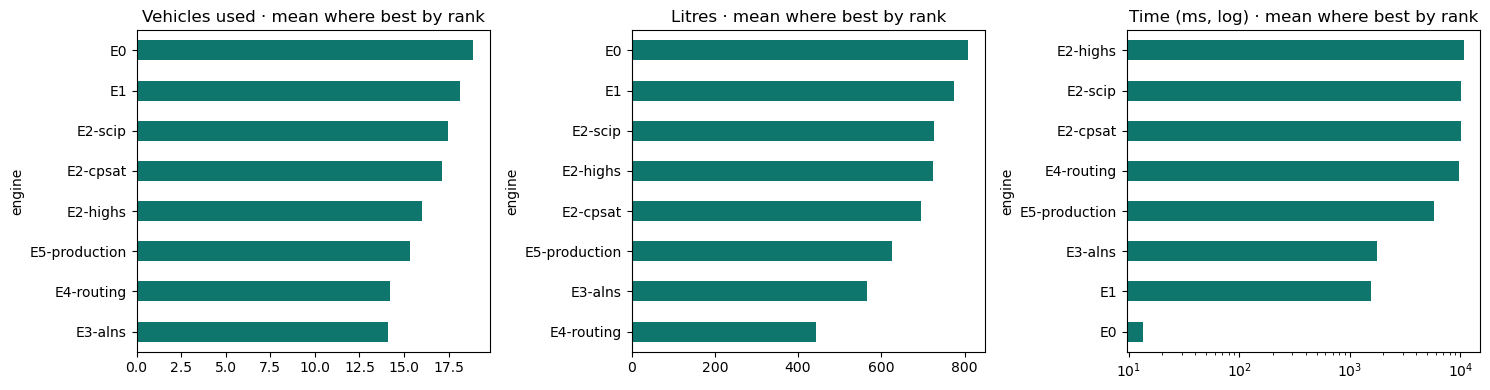

In [3]:
best = df[(df["rank_vs_best"] == 0) & df["valid"]]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, ["vehicles", "litres", "ms"], ["Vehicles used", "Litres", "Time (ms, log)"]):
    best.groupby("engine")[col].mean().sort_values().plot.barh(ax=ax, color="#0E766D")
    ax.set_title(title + " · mean where best by rank")
    if col == "ms":
        ax.set_xscale("log")
plt.tight_layout()
plt.show()

## By family

How often each engine is best by rank, per kind of day.

In [4]:
wins = df.assign(best=(df["rank_vs_best"] == 0) & df["valid"]).pivot_table(
    index="family", columns="engine", values="best", aggfunc="mean").round(2)
wins.style.background_gradient(cmap="Greens", axis=None)

engine,E0,E1,E2-cpsat,E2-highs,E2-scip,E3-alns,E4-routing,E5-production
family,,,,,,,,
base-120,0.400000,0.400000,0.400000,nan,0.400000,0.600000,0.000000,1.000000
base-200,0.000000,0.000000,0.000000,nan,0.000000,0.000000,0.000000,1.000000
base-60,0.400000,0.600000,1.000000,nan,1.000000,1.000000,0.600000,1.000000
big-orders,0.400000,0.400000,0.800000,nan,0.400000,0.600000,0.000000,0.800000
historic,0.500000,0.670000,0.790000,nan,0.710000,0.790000,0.330000,1.000000
large-300,0.000000,0.000000,0.000000,nan,0.000000,0.000000,0.000000,1.000000
official,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
prior-skips,0.400000,0.400000,0.800000,nan,0.400000,0.600000,0.000000,0.600000
reefer-short,0.000000,0.000000,0.000000,nan,0.000000,0.000000,0.200000,0.800000


## ALNS against the rules plan

The cost stage keeps the served set (R-PLN-38); vehicles and litres saved per scenario.

In [5]:
pair = df[df["engine"].isin(["E1", "E3-alns"])].pivot_table(index="scenario", columns="engine", values=["vehicles", "litres", "served"])
saved = pd.DataFrame({
    "served_same": pair[("served", "E1")] == pair[("served", "E3-alns")],
    "vehicles_saved": pair[("vehicles", "E1")] - pair[("vehicles", "E3-alns")],
    "litres_saved": (pair[("litres", "E1")] - pair[("litres", "E3-alns")]).round(1),
    "litres_saved_pct": (100 * (pair[("litres", "E1")] - pair[("litres", "E3-alns")]) / pair[("litres", "E1")]).round(1),
})
print(saved[["vehicles_saved", "litres_saved", "litres_saved_pct"]].describe().round(1))
saved.sort_values("litres_saved_pct", ascending=False).head(15)

       vehicles_saved  litres_saved  litres_saved_pct
count            62.0          62.0              62.0
mean              2.1          98.7              13.8
std               2.4         109.4              13.1
min               0.0         -40.1              -5.8
25%               0.0           0.0               0.0
50%               1.0          82.8              16.4
75%               4.0         174.3              25.9
max               7.0         352.4              35.3


,served_same,vehicles_saved,litres_saved,litres_saved_pct
scenario,,,,
H-2026-02-14-Kan-out25,True,2.0,176.6,35.3
H-2026-02-14-Kan-out0,True,2.0,172.6,35.2
H-2026-02-09-Pel-out0,True,4.0,304.5,34.9
G-prior-skips-4,True,7.0,352.4,32.9
H-2026-02-09-Pel-out25,True,4.0,271.1,31.2
G-base-60-1,False,4.0,155.2,30.9
G-tight-fuel-3,True,6.0,314.8,29.5
G-prior-skips-5,True,7.0,273.8,29.5
H-2026-02-12-Kan-out25,True,3.0,131.2,28.5


## S1, the official peak day

In [6]:
df[df["scenario"] == "S1"][["engine", "valid", "served", "chilled_served", "vehicles", "trips", "litres", "ms", "rank_vs_best", "extra"]]

,engine,valid,served,chilled_served,vehicles,trips,litres,ms,rank_vs_best,extra
0,E0,True,70,12,16,32,712.873,167,-1,NaN
1,E1,True,73,15,16,32,724.807,456,0,NaN
2,E2-cpsat,True,73,15,16,32,724.807,10071,0,solves=12 cuts=0 unproven=0 cost=unfinished ob...
3,E2-highs,True,73,15,16,32,724.807,10782,0,solves=4 cuts=0 unproven=7 cost=unfinished obj...
4,E2-scip,True,73,15,16,32,724.807,10044,0,solves=12 cuts=0 unproven=0 cost=unfinished ob...
5,E3-alns,True,73,15,14,28,633.654,691,0,iterations=2000 improvements=14
6,E4-routing,True,70,12,15,22,652.486,10120,-1,repaired=1 status=ROUTING_SUCCESS
7,E5-production,True,73,15,13,25,610.620,659,0,cost=DEFERRALS vehicles 16->13 litres 724.8->6...


## Reading the results

- **Priority, proven.** The exact MIP (E2, CP-SAT) proved the best set of orders by rank on 34 of the 62 days. On **all 34**, the production chain (E5: rules, the exact reefer pass, then ALNS) serves exactly that set. The rules alone (E1) fall one or two orders short on 6 of them; the cost stage's search recovers those orders too, because it accepts any plan better by rank before it looks at cost.
- **Best overall.** E5 is best or tied by rank on 58 of 62 days, serves the most orders (5,464) on the fewest vehicles (954), with the least fuel among the plans that serve that much.
- **Cost.** Against the rules plan, the cost stage saves a median of 16% of the fuel (up to 35%) and up to 7 vehicles a day, every placement checked by the production registry.
- **OR-Tools routing (E4)** is best on only 13 days: penalties approximate a strict priority order, and one brand and district per trip is awkward to state as routing constraints.
- **The MIP as an engine** is slower (10 s budget, often unproven on large days) and serves fewer in total when it runs out of time; it stays here as the proof, not in production.
- **HiGHS** through OR-Tools 9.14 crashes when given a start solution and ignores its time limit on these models, so it runs on S1 only.
- **Found by this benchmark and fixed:** the reefer pass's day listing was unbounded (a 200-order day held a worker for over an hour; now bounded, PLN-39), and the cost stage now has its own time budget so a long reefer search no longer starves it.

So production runs `ValidatingEngine(CostImprovingEngine(ImprovingEngine(PriorityInsertionEngine)))`; simple days skip the cost stage.